## Dummy inference

In [17]:

import os
import numpy as np
import hydra
import torch
import dill
from omegaconf import OmegaConf, open_dict
from termcolor import cprint
from diffusion_policy.workspace.base_workspace import BaseWorkspace
from diffusion_policy.model.common.normalizer import LinearNormalizer


In [7]:


def setup_noise_schedule(cfg, noise_scheduler, num_inference_steps=None):
    if noise_scheduler.lower() == "ddpm":
        if cfg.policy.noise_scheduler['_target_'] == 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler':
            cprint(f"Skip setup scheduler: Pretrained model already used DDPM scheduler", "green")
        else:
            with open_dict(cfg.policy.noise_scheduler):
                cfg.policy.noise_scheduler = OmegaConf.create({
                    '_target_': 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler',
                    'num_train_timesteps': 100,
                    'beta_start': 0.0001,
                    'beta_end': 0.02,
                    'beta_schedule': 'squaredcos_cap_v2',
                    'variance_type': 'fixed_small',
                    'clip_sample': True,
                    'prediction_type': 'epsilon'
                })
    elif noise_scheduler.lower() == "ddim":
        if cfg.policy.noise_scheduler['_target_'] == 'diffusers.schedulers.scheduling_ddim.DDIMScheduler':
            cprint(f"Skip setup scheduler: Pretrained model already used DDIM scheduler", "green")
        else:
            with open_dict(cfg.policy.noise_scheduler):
                cfg.policy.noise_scheduler = OmegaConf.create({
                    '_target_': 'diffusers.schedulers.scheduling_ddim.DDIMScheduler',
                    'num_train_timesteps': 100,
                    'beta_start': 0.0001,
                    'beta_end': 0.02,
                    'beta_schedule': 'squaredcos_cap_v2',
                    'clip_sample': True,
                    'set_alpha_to_one': True,
                    'steps_offset': 0,
                    'prediction_type': 'epsilon'
                })
    else:
        raise ValueError(f"Unknown noise scheduler {noise_scheduler}")

    if num_inference_steps is not None:
        cfg.policy.num_inference_steps = num_inference_steps
    cprint(f"Noise Scheduler: {noise_scheduler.upper()}-{cfg.policy.num_inference_steps}", "green")
    print(OmegaConf.to_yaml(cfg.policy.noise_scheduler))
    return cfg


In [ ]:


checkpoint = '/pfss/mlde/workspaces/mlde_wsp_MGPATH/VLA/lpb_libero/logs/reproduce/aloha_image/None/2026.06.02_03.50.28_train_diffusion_unet_hybrid_aloha_image/checkpoints/0.ckpt'
payload = torch.load(open(checkpoint, 'rb'), pickle_module=dill)

cfg = payload['cfg']
cls = hydra.utils.get_class(cfg._target_)
cfg = setup_noise_schedule(cfg, noise_scheduler='ddpm', num_inference_steps=100)

workspace = cls(cfg)
workspace: BaseWorkspace
exclude_keys = ['optimizer']
workspace.load_payload(payload, exclude_keys=exclude_keys, include_keys=None)

# get policy from workspace
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

policy = workspace.model
if cfg.training.use_ema:
    policy = workspace.ema_model

device = torch.device(device)
policy.to(device)
policy.eval()

Skip setup scheduler: Pretrained model already used DDPM scheduler
Noise Scheduler: DDPM-100
_target_: diffusers.schedulers.scheduling_ddpm.DDPMScheduler
beta_end: 0.02
beta_schedule: squaredcos_cap_v2
beta_start: 0.0001
clip_sample: true
num_train_timesteps: 100
prediction_type: epsilon
variance_type: fixed_small



In [ ]:
### Load normalizer
normalizer_path = os.path.join(os.path.dirname(os.path.dirname(checkpoint)), "normalizer.pth")
print("loading normalizer from", normalizer_path)
state_dict = torch.load(normalizer_path, map_location="cpu")
policy.normalizer = LinearNormalizer()
policy.normalizer.load_state_dict(state_dict)
policy.normalizer.to(device)

In [26]:
policy.reset()

obs = {
    'high_images': np.zeros((1, 2, 3, 480, 640)),
    'wrist_left_images': np.zeros((1, 2, 3, 480, 640)),
    'wrist_right_images': np.zeros((1, 2, 3, 480, 640)),
    'states': np.zeros((1, 2, 14))
}
action_dict = policy.predict_action(obs)
action = action_dict['action'].detach().to('cpu').numpy()
action.shape


(1, 15, 14)

## Convert lerobot to hdf5

In [ ]:
# import pandas as pd
# import glob
# import os
# import h5py
# import imageio.v3 as iio
# import numpy as np
# from tqdm import tqdm


# data_root = 'logs/aloha-short-folding-4pi0'

# all_file_name = os.listdir(os.path.join(data_root, 'data/chunk-000'))
# all_file_name = [i.split('.')[0] for i in all_file_name]
# all_file_name.sort()

# print(all_file_name)

# data_writer = h5py.File('data/aloha/fold_shirt/fold_shirt_debug.hdf5', "w")
# data_grp = data_writer.create_group("data")


# for i, file_name in tqdm(enumerate(all_file_name[:5])):
#     lowdim_path = os.path.join(data_root, 'data/chunk-000', f'{file_name}.parquet')
#     high_video_path = os.path.join(data_root, 'videos/chunk-000', 'observation.images.color.high', f'{file_name}.mp4')
#     left_video_path = os.path.join(data_root, 'videos/chunk-000', 'observation.images.color.wrist_left', f'{file_name}.mp4')
#     right_video_path = os.path.join(data_root, 'videos/chunk-000', 'observation.images.color.wrist_right', f'{file_name}.mp4')


#     high_video = iio.imread(high_video_path)
#     left_video = iio.imread(left_video_path)
#     right_video = iio.imread(right_video_path)
    

#     df = pd.read_parquet(lowdim_path)


#     ep_data_grp = data_grp.create_group(f"demo_{i}")

#     obs_grp = ep_data_grp.create_group("obs")
#     obs_grp.create_dataset("high_images", data=high_video)
#     obs_grp.create_dataset("wrist_left_images", data=left_video)
#     obs_grp.create_dataset("wrist_right_images", data=right_video)
#     obs_grp.create_dataset("states", data=np.stack(df['observation.state'].to_numpy()))
    
#     ep_data_grp.create_dataset("actions", data=np.stack(df['action'].to_numpy()))
#     ep_data_grp.create_dataset("abs_actions", data=np.stack(df['action'].to_numpy()))
#     ep_data_grp.create_dataset("rewards", data=np.zeros(len(high_video)))
#     ep_data_grp.create_dataset("states", data=np.stack(df['observation.state'].to_numpy()))

#     dones = np.zeros(len(high_video), dtype=np.uint8)
#     dones[-1] = 1
#     successes = np.zeros(len(high_video), dtype=np.uint8)
#     successes[-1] = 1
#     ep_data_grp.create_dataset("dones", data=dones) # this may not contain any done
#     ep_data_grp.create_dataset("successes", data=successes)

# data_writer.close()


# # print("Columns:")
# # for col in df.columns:
# #     print(col)

# # print("\nFirst row:")
# # for k, v in df.iloc[0].items():
# #     print(f"\n{k}:")
# #     print(v)

['episode_000000', 'episode_000001', 'episode_000002', 'episode_000003', 'episode_000004', 'episode_000005', 'episode_000006', 'episode_000007', 'episode_000008', 'episode_000009', 'episode_000010', 'episode_000011', 'episode_000012', 'episode_000013', 'episode_000014', 'episode_000015', 'episode_000016', 'episode_000017', 'episode_000018', 'episode_000019', 'episode_000020', 'episode_000021', 'episode_000022', 'episode_000023', 'episode_000024', 'episode_000025', 'episode_000026', 'episode_000027', 'episode_000028', 'episode_000029', 'episode_000030', 'episode_000031', 'episode_000032', 'episode_000033', 'episode_000034', 'episode_000035', 'episode_000036', 'episode_000037', 'episode_000038', 'episode_000039', 'episode_000040', 'episode_000041', 'episode_000042', 'episode_000043', 'episode_000044', 'episode_000045', 'episode_000046', 'episode_000047', 'episode_000048', 'episode_000049', 'episode_000050', 'episode_000051', 'episode_000052', 'episode_000053', 'episode_000054', 'episode_

5it [00:06,  1.38s/it]


In [43]:
data_writer.close()


In [40]:
actions = np.stack(df['observation.'].to_numpy())
actions.shape

(216, 14)

In [47]:
file = 'logs/aloha_demo.hdf5'
f = h5py.File(file, "r")
f.keys()


<KeysViewHDF5 ['data']>

In [48]:
f['data'].keys()

<KeysViewHDF5 ['demo_0']>

In [50]:
f['data']['demo_0'].keys()

<KeysViewHDF5 ['abs_actions', 'actions', 'dones', 'obs', 'rewards', 'states', 'successes']>

In [51]:
f['data']['demo_0']['obs'].keys()

<KeysViewHDF5 ['high_images', 'states', 'wrist_left_images', 'wrist_right_images']>

In [52]:
f['data']['demo_0']['obs']['wrist_right_images'].shape

(216, 480, 640, 3)

In [1]:
import os
import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from decord import VideoReader
from IPython.display import HTML
import base64
import imageio
import h5py

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.transforms import Normalize

root_path = '/pfss/mlde/workspaces/mlde_wsp_MGPATH/VLA/lpb_libero'


def video_tag(path):
    video = open(path, "rb").read()
    encoded = base64.b64encode(video).decode()
    return f'<video width="400" controls><source src="data:video/mp4;base64,{encoded}" type="video/mp4"></video>'

def save_frames_as_mp4(video_path, output_path, start=0, end=30):
    vr = VideoReader(video_path)
    
    # Get first N frames (batch for speed)
    indices = list(range(start, min(end, len(vr))))
    frames = vr.get_batch(indices).asnumpy()  # (N, H, W, C), RGB

    # Write video
    imageio.mimsave(
        output_path,
        frames,
        fps=vr.get_avg_fps(),
        codec='libx264'  # ensures proper mp4 encoding
    )

class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = models.resnet50(weights="ResNet50_Weights.IMAGENET1K_V1")
        self.normalizer = Normalize(mean=torch.FloatTensor([0.485, 0.456, 0.406]),
                                    std=torch.FloatTensor([0.229, 0.224, 0.225]))

    def forward(self, obs, spacial=True, normalize=True):
        obs = obs[:, -3:] / 255.0 
        h = self.normalizer(obs)
        i = 0
        for m in list(self.encoder.children()):
            i += 1
            if i <= 8:
                h = m(h)
        h = h.view(obs.shape[0], -1)
        return h


/pfss/mlde/workspaces/mlde_wsp_MGPATH/miniconda3/envs/lpb/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Collected Data

In [19]:
file = '/pfss/mlde/workspaces/mlde_wsp_MGPATH/VLA/lpb_libero/data/transport/transport_ph_demo_v141_20_perc.hdf5'
f = h5py.File(file, "r")


rollout_file = '/pfss/mlde/workspaces/mlde_wsp_MGPATH/VLA/lpb_libero/logs/transport_collect_data_2eps/_/collect_transport.hdf5'
rollout_f = h5py.File(rollout_file, "r")



In [20]:
f['data'].keys()

<KeysViewHDF5 ['demo_0', 'demo_1', 'demo_10', 'demo_11', 'demo_12', 'demo_13', 'demo_14', 'demo_15', 'demo_16', 'demo_17', 'demo_18', 'demo_19', 'demo_2', 'demo_20', 'demo_21', 'demo_22', 'demo_23', 'demo_24', 'demo_25', 'demo_26', 'demo_27', 'demo_28', 'demo_29', 'demo_3', 'demo_30', 'demo_31', 'demo_32', 'demo_33', 'demo_34', 'demo_35', 'demo_36', 'demo_37', 'demo_38', 'demo_39', 'demo_4', 'demo_5', 'demo_6', 'demo_7', 'demo_8', 'demo_9']>

In [21]:
rollout_f['data'].keys()

<KeysViewHDF5 ['demo_0', 'demo_1']>

In [22]:
sample = f['data']['demo_0']
sample.keys()

<KeysViewHDF5 ['abs_actions', 'actions', 'dones', 'obs', 'rewards', 'states']>

In [23]:
rollout_sample = rollout_f['data']['demo_0']
rollout_sample.keys()

<KeysViewHDF5 ['abs_actions', 'actions', 'dones', 'next_obs', 'obs', 'rewards', 'states', 'successes']>

In [24]:
sorted(list(sample['obs'].keys()))

['object',
 'robot0_eef_pos',
 'robot0_eef_quat',
 'robot0_eef_vel_ang',
 'robot0_eef_vel_lin',
 'robot0_eye_in_hand_image',
 'robot0_gripper_qpos',
 'robot0_gripper_qvel',
 'robot0_joint_pos',
 'robot0_joint_pos_cos',
 'robot0_joint_pos_sin',
 'robot0_joint_vel',
 'robot1_eef_pos',
 'robot1_eef_quat',
 'robot1_eef_vel_ang',
 'robot1_eef_vel_lin',
 'robot1_eye_in_hand_image',
 'robot1_gripper_qpos',
 'robot1_gripper_qvel',
 'robot1_joint_pos',
 'robot1_joint_pos_cos',
 'robot1_joint_pos_sin',
 'robot1_joint_vel',
 'shouldercamera0_image',
 'shouldercamera1_image']

In [25]:
sorted(list(rollout_sample['obs'].keys()))

['robot0_eef_pos',
 'robot0_eef_quat',
 'robot0_eye_in_hand_image',
 'robot0_gripper_qpos',
 'robot1_eef_pos',
 'robot1_eef_quat',
 'robot1_eye_in_hand_image',
 'robot1_gripper_qpos',
 'shouldercamera0_image',
 'shouldercamera1_image']

In [34]:
sample.keys()

<KeysViewHDF5 ['abs_actions', 'actions', 'dones', 'obs', 'rewards', 'states']>

In [36]:
for key in rollout_sample['obs'].keys():
    print(f"Key: {key}, demo: {sample['obs'][key].shape}, rollout: {rollout_sample['obs'][key].shape}")

Key: robot0_eef_pos, demo: (714, 3), rollout: (15, 3)
Key: robot0_eef_quat, demo: (714, 4), rollout: (15, 4)
Key: robot0_eye_in_hand_image, demo: (714, 140, 140, 3), rollout: (15, 140, 140, 3)
Key: robot0_gripper_qpos, demo: (714, 2), rollout: (15, 2)
Key: robot1_eef_pos, demo: (714, 3), rollout: (15, 3)
Key: robot1_eef_quat, demo: (714, 4), rollout: (15, 4)
Key: robot1_eye_in_hand_image, demo: (714, 140, 140, 3), rollout: (15, 140, 140, 3)
Key: robot1_gripper_qpos, demo: (714, 2), rollout: (15, 2)
Key: shouldercamera0_image, demo: (714, 140, 140, 3), rollout: (15, 140, 140, 3)
Key: shouldercamera1_image, demo: (714, 140, 140, 3), rollout: (15, 140, 140, 3)


In [ ]:
sample['obs']['robot0_eef_quat'].shape

(714, 140, 140, 3)

In [27]:
rollout_sample['obs']['shouldercamera0_image'].dtype


dtype('uint8')

In [28]:
rollout_sample['obs']['shouldercamera0_image'].shape

(15, 140, 140, 3)

In [32]:
sample['rewards'][:]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [33]:
np.sum(sample['rewards'])

0.0

In [14]:
sample['joint_states'].shape

(272, 7)

In [21]:
import glob

hdf5_files = glob.glob('data/libero_10/libero_10' + "/*.hdf5")
task_name = [file.split("/")[-1].split(".")[0] for file in hdf5_files]

for task in task_name:
    for eps_idx in range(500):
        eps = f'episode_{eps_idx}'
        data_path = f'{root_path}/logs/collect_data/libero_10/datacollect_diffusion_unet_libero_10/collect_{task}.hdf5'
        f = h5py.File(data_path, "r")

        assert len(f['data']) == 500
        sample = f['data'][eps]

        ### check if length video
        video_dir = f'{root_path}/logs/collect_data/libero_10/datacollect_diffusion_unet_libero_10/videos_{task}'
        video = VideoReader(f'{video_dir}/{eps}.mp4')

        assert sample['agentview_image'].shape[0] == sample['actions'].shape[0] == len(video)
    print(f"{task} -----> OK !!!!!!")

# print(np.argmax(cur_ep_reward))

KITCHEN_SCENE3_turn_on_the_stove_and_put_the_moka_pot_on_it_demo -----> OK !!!!!!
LIVING_ROOM_SCENE2_put_both_the_cream_cheese_box_and_the_butter_in_the_basket_demo -----> OK !!!!!!
STUDY_SCENE1_pick_up_the_book_and_place_it_in_the_back_compartment_of_the_caddy_demo -----> OK !!!!!!
LIVING_ROOM_SCENE1_put_both_the_alphabet_soup_and_the_cream_cheese_box_in_the_basket_demo -----> OK !!!!!!
LIVING_ROOM_SCENE2_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket_demo -----> OK !!!!!!
KITCHEN_SCENE8_put_both_moka_pots_on_the_stove_demo -----> OK !!!!!!
KITCHEN_SCENE6_put_the_yellow_and_white_mug_in_the_microwave_and_close_it_demo -----> OK !!!!!!
KITCHEN_SCENE4_put_the_black_bowl_in_the_bottom_drawer_of_the_cabinet_and_close_it_demo -----> OK !!!!!!
LIVING_ROOM_SCENE5_put_the_white_mug_on_the_left_plate_and_put_the_yellow_and_white_mug_on_the_right_plate_demo -----> OK !!!!!!
LIVING_ROOM_SCENE6_put_the_white_mug_on_the_plate_and_put_the_chocolate_pudding_to_the_right_of_the_plate_d

# Visualization: Collected Data

In [16]:
# file_1 = f"{root_path}/logs/collect_data/lift_lowdim/datacollect_diffusion_transformer_lowdim_lift_lowdim/media/episode_20.mp4"
# file_1 = f"/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/lift/ph/videos/demo_0_res256_agentview.mp4"
# file_1 = f"/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/can/ph/videos/demo_0_res256_agentview.mp4"
# video = VideoReader(file_1)
# frames = video.get_batch(np.arange(0, len(video))).asnumpy()
# video_1 = VideoReader("/mnt/workspace/vla_bench/diffusion_policy/logs/collect_data/lift_lowdim/datacollect_diffusion_transformer_lowdim_lift_lowdim/videos/episode_0.mp4")
# video_2 = VideoReader("/mnt/workspace/vla_bench/diffusion_policy/logs/collect_data/lift_lowdim/datacollect_diffusion_transformer_lowdim_lift_lowdim/media/episode_0.mp4")
# frames_1 = video_1.get_batch(np.arange(len(video_1))).asnumpy()
# frames_2 = video_2.get_batch(np.arange(len(video_2))).asnumpy()

# tmp_file = "/mnt/workspace/vla_bench/diffusion_policy/trash/short.mp4"
# save_frames_as_mp4(file_1, "/mnt/workspace/vla_bench/diffusion_policy/trash/first.mp4", start=0, end=50)
# save_frames_as_mp4(file_1, "/mnt/workspace/vla_bench/diffusion_policy/trash/last.mp4", start=len(frames) - 50, end=len(frames))


# Lift
HTML(f"""
<div style="display: flex; gap: 10px;">
    {video_tag("/mnt/workspace/vla_bench/diffusion_policy/logs/collect_data/lift_lowdim/datacollect_diffusion_transformer_lowdim_lift_lowdim/videos/episode_0.mp4")}
</div>
""")

# Can
# HTML(f"""
# <div style="display: flex; gap: 10px;">
#     {video_tag("/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/can/mh/videos/demo_0_res256_agentview.mp4")}
#     {video_tag("/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/can/mh/videos/demo_2_res256_agentview.mp4")}
# </div>
# """)

# print(len(video))
# print(frames.shape)
# plt.imshow(frames[0])

# Visualization: Expert

In [29]:
# expert_video = f"/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/lift/ph/videos/demo_0_res256_agentview.mp4"
# expert_video = f"/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/can/ph/videos/demo_0_res256_agentview.mp4"

HTML(f"""
<div style="display: flex; gap: 10px;">
    {video_tag("/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/can/mh/videos/demo_0_res256_agentview.mp4")}
    {video_tag("/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/can/mh/videos/demo_1_res256_agentview.mp4")}
    {video_tag("/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/can/ph/videos/demo_0_res256_agentview.mp4")}
</div>
""")

# Test ORCA

In [47]:
def get_context_observations(observations, context_num=3):
    L = len(observations)
    idx0 = np.arange(L)
    context_observations = [observations[idx0]]
    for i in range(1, context_num):
        idx_i = (idx0 + i).clip(0, L-1)
        context_observations.append(observations[idx_i])
    context_observations = torch.stack(context_observations)
    return context_observations

def cosine_distance(x, y):
    C = torch.mm(x, y.T)
    x_norm = torch.norm(x, p=2, dim=1)
    y_norm = torch.norm(y, p=2, dim=1)
    x_n = x_norm.unsqueeze(1)
    y_n = y_norm.unsqueeze(1)
    norms = torch.mm(x_n, y_n.T)
    C = (1 - C / norms)
    return C

def compute_orca_reward(cost_matrix, tau=1):

    """
    # max of orca in previous learner timestep, orca in current learner timestep up to previous state and occupying current state
    covered[t, t'] = max(covered[t-1, t'], covered[t, t'-1] * exp(-cost(t, t')) ) 
    covered[:, -1] = 1 # ref -1 is always covered
    covered[-1, :] = 0 # nothing has been covered by learner frame -1
    """
    prob_matrix = np.exp(-cost_matrix / tau)

    covered = np.zeros_like(prob_matrix)
    covered[0,0] = prob_matrix[0,0]

    # Init coverage of first demo frame j = 0
    for i in range(1, covered.shape[0]):
        covered[i, 0] = max(covered[i-1, 0], prob_matrix[i, 0])

    # Init coverage at learner time t = 0
    for j in range(1, covered.shape[1]):
        covered[0, j] = covered[0, j-1] * prob_matrix[0, j]

    # Solve recurrence relation
    for i in range(1, covered.shape[0]):
        for j in range(1, covered.shape[1] - 1):
            covered[i,j] = max(covered[i-1, j], covered[i, j-1] * prob_matrix[i, j])
    
    covered[:, -1] = covered[:, -2] * prob_matrix[:, -1]

    # final_reward = orca_scaled_probabilities.sum(axis=1)
    final_reward = covered[:, -1]
    return final_reward, {"assignment": covered}

# Can task

Exp len=118, seg_left len=142, seg_right len=113
rew_0 len=118, rew_1 len=142, rew_2 len = 113
rew_0 max=1.0000561475753784, rew_1 max=3.6587675822374877e-07, rew_2 max=2.0614392269635573e-05


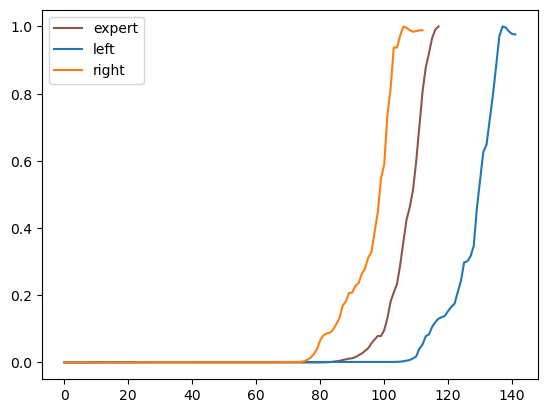

In [50]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
cost_encoder = ResNet().to(device)
_ = cost_encoder.eval()

# Read video
exp_video_reader = VideoReader("/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/can/ph/videos/demo_0_res256_agentview.mp4")
# seg_left_reader = VideoReader("/mnt/workspace/rlhf_bench/ipl/datasets/robo/pref_clip_segment_numq10000/can_mh/agentview/res256_seg0_1.mp4")
# seg_right_reader = VideoReader("/mnt/workspace/rlhf_bench/ipl/datasets/robo/pref_clip_segment_numq10000/can_mh/agentview/res256_seg0_2.mp4")

seg_left_reader = VideoReader("/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/can/mh/videos/demo_4_res256_agentview.mp4")
seg_right_reader = VideoReader("/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/can/mh/videos/demo_2_res256_agentview.mp4")

# Convert to numpy
expert_video = exp_video_reader.get_batch(np.arange(0, len(exp_video_reader))).asnumpy()
seg_left = seg_left_reader.get_batch(np.arange(0, len(seg_left_reader))).asnumpy()
seg_right = seg_right_reader.get_batch(np.arange(0, len(seg_right_reader))).asnumpy()

# TODO: Override
# seg_left = np.concatenate((seg_left[:60], seg_left[:58]))

# Resize
expert_video_resize = [cv2.resize(np.array(frame), (224, 224)) for frame in expert_video]
seg_left_resize = [cv2.resize(np.array(frame), (224, 224)) for frame in seg_left]
seg_right_resize = [cv2.resize(np.array(frame), (224, 224)) for frame in seg_right]

# Convert to tensor
expert_video_torch = torch.stack([torch.tensor(frame).permute(2, 0, 1) for frame in expert_video_resize]).float()
seg_left_torch = torch.stack([torch.tensor(frame).permute(2, 0, 1) for frame in seg_left_resize]).float()
seg_right_torch = torch.stack([torch.tensor(frame).permute(2, 0, 1) for frame in seg_right_resize]).float()
print(f"Exp len={len(expert_video_torch)}, seg_left len={len(seg_left_torch)}, seg_right len={len(seg_right_torch)}")

# Extract feature: (88, 3, 224, 224) ==> (88, 2048, 7, 7) ==> (88, 100352)
with torch.no_grad():
    expert_demo_feat = cost_encoder(expert_video_torch.to(device)).cpu()
    seg_1_feat = cost_encoder(seg_left_torch.to(device)).cpu()
    seg_2_feat = cost_encoder(seg_right_torch.to(device)).cpu()

# Make context
expert_demo_feat_context = get_context_observations(expert_demo_feat)
seg_1_feat_context = get_context_observations(seg_1_feat)
seg_2_feat_context = get_context_observations(seg_2_feat)

# Calculate distance
context_num = 3
distance_matrix_0 = 0
for i in range(context_num):
    distance_matrix_0 += cosine_distance(expert_demo_feat_context[i], expert_demo_feat_context[i])
distance_matrix_0 /= context_num

distance_matrix_1 = 0
for i in range(context_num):
    distance_matrix_1 += cosine_distance(seg_1_feat_context[i], expert_demo_feat_context[i])
distance_matrix_1 /= context_num

distance_matrix_2 = 0
for i in range(context_num):
    distance_matrix_2 += cosine_distance(seg_2_feat_context[i], expert_demo_feat_context[i])
distance_matrix_2 /= context_num

# Calculate rewards
rewards_0, info_0 = compute_orca_reward(distance_matrix_0.cpu().numpy())
rewards_1, info_1 = compute_orca_reward(distance_matrix_1.cpu().numpy())
rewards_2, info_2 = compute_orca_reward(distance_matrix_2.cpu().numpy())
print(f"rew_0 len={len(rewards_0)}, rew_1 len={len(rewards_1)}, rew_2 len = {len(rewards_2)}")
print(f"rew_0 max={rewards_0.max()}, rew_1 max={rewards_1.max()}, rew_2 max={rewards_2.max()}")
plt.plot(rewards_0 / rewards_0.max(), color='tab:brown', label="expert")
plt.plot(rewards_1 / rewards_1.max(), color='tab:blue', label="left")
plt.plot(rewards_2 / rewards_2.max(), color='tab:orange', label="right")
# plt.plot(rewards_0, color='tab:brown', label="expert")
# plt.plot(rewards_1, color='tab:blue', label="left")
# plt.plot(rewards_2, color='tab:orange', label="right")
plt.legend()
plt.show()

# Lift

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
cost_encoder = ResNet().to(device)
_ = cost_encoder.eval()

expert_video_reader = VideoReader("/mnt/workspace/vla_bench/diffusion_policy/data/robomimic/datasets/lift/ph/videos/demo_0_res256_agentview.mp4")
expert_video = expert_video_reader.get_batch(np.arange(0, len(expert_video_reader))).asnumpy()

video_1 = VideoReader("/mnt/workspace/rlhf_bench/ipl/datasets/robo/pref_clip_segment_numq10000/lift_mh/agentview/res256_seg3_1.mp4")
video_2 = VideoReader("/mnt/workspace/rlhf_bench/ipl/datasets/robo/pref_clip_segment_numq10000/lift_mh/agentview/res256_seg3_2.mp4")


seg_1 = video_1.get_batch(np.arange(0, len(video_1))).asnumpy()
seg_2 = video_2.get_batch(np.arange(0, len(video_2))).asnumpy()

expert_video_resize = [cv2.resize(np.array(frame), (224, 224)) for frame in expert_video]
seg_1_resize = [cv2.resize(np.array(frame), (224, 224)) for frame in seg_1]
seg_2_resize = [cv2.resize(np.array(frame), (224, 224)) for frame in seg_2]

expert_video_torch = torch.stack([torch.tensor(frame).permute(2, 0, 1) for frame in expert_video_resize])
expert_video_torch = expert_video_torch.float()
seg_torch_1 = torch.stack([torch.tensor(frame).permute(2, 0, 1) for frame in seg_1_resize])
seg_torch_1 = seg_torch_1.float()
seg_torch_2 = torch.stack([torch.tensor(frame).permute(2, 0, 1) for frame in seg_2_resize])
seg_torch_2 = seg_torch_2.float()